# Phase 1 — KITTI 데이터 로드 (실무 방식 재구성)

정답지 `notebooks/01_kitti_data_check.ipynb` 와 `src/perceptrack3d/data/kitti_loader.py` 가 하는 일을,
**검색해서 원본을 가져다 붙이는 방식**으로 다시 만든다. 조각마다 A(원본 발췌) → B(우리 데이터에 적용) → C(정답지와 검증) 순서.

## 이 노트북에서 가져오는 것

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. Velodyne `.bin` → `(N, 4)` | KITTI raw devkit `readme.txt` "Velodyne 3D laser scan data" 절 + pykitti `utils.load_velo_scan` + `numpy.fromfile` 문서 | KITTI(연구용) / MIT / NumPy 문서 | `.bin` 은 헤더가 없어서 포맷을 문서로 확인해야 `reshape` 할 수 있다 |
| 2. `cv2.imread` 는 BGR | OpenCV `imgcodecs.hpp` 의 `imread` 문서 주석 + 튜토리얼 샘플 `display_image.py` | Apache-2.0 | matplotlib·YOLO 는 RGB 를 기대하므로 채널 순서를 알아야 한다 |
| 3. 프레임 목록 만들기 | pykitti `raw._get_file_lists` | MIT | 파일명 번호 = 프레임 번호. 두 센서 폴더의 번호 집합이 같아야 동기화가 성립 |
| 4. `timestamps.txt` 읽기 | `readme.txt` "General information about streams and timestamps" 절 + pykitti `raw._load_timestamps` | KITTI / MIT | 10 Hz 인지, 이미지·LiDAR 시각이 얼마나 어긋나는지 직접 잰다 |
| 5. BEV 산점도 | matplotlib plot_types `scatter_plot.py` + `Axes.scatter` API 문서 | matplotlib(PSF 계열) | 점군을 위에서 내려다본 x‑y 산점도(색 = 높이 z)가 가장 빠른 확인 수단 |

용어
- **BEV**(bird's-eye view): 위에서 내려다본 x‑y 평면 그림.
- **동기화(sync) 시퀀스**: 카메라와 LiDAR 프레임에 같은 번호를 붙여 둔 데이터. 같은 번호 = 같은 시각.
- **reflectance(반사 강도)**: 레이저가 되돌아온 세기, 0~1.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config, REPO_ROOT   # 경로는 여기서만 만든다 (configs/kitti.yaml)
cfg = load_config()
ds = cfg["dataset"]

FRAME = 0
NAME = f"{FRAME:0{ds['frame_id_width']}d}"           # '0000000000'
IMG_PATH = Path(ds["image_dir"]) / f"{NAME}.png"
BIN_PATH = Path(ds["velo_dir"]) / f"{NAME}.bin"
SOURCES = REPO_ROOT / "notebooks_2nd" / "sources"   # 가져온 원본 파일들

# 조각 2 의 원본(display_image.py)이 cv.samples.findFile("starry_night.jpg") 로 예제 이미지를 찾을 수 있게 검색 경로를 등록
import cv2 as cv
cv.samples.addSamplesDataSearchPath(str(SOURCES / "opencv"))

print("image_dir :", ds["image_dir"])
print("velo_dir  :", ds["velo_dir"])
print("frame 0   :", IMG_PATH.name, IMG_PATH.exists(), "|", BIN_PATH.name, BIN_PATH.exists())
print("sources   :", SOURCES, SOURCES.is_dir())

image_dir : /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/image_02/data
velo_dir  : /home/ingon/datasets/KITTI/raw/2011_09_26/2011_09_26_drive_0015_sync/velodyne_points/data
frame 0   : 0000000000.png True | 0000000000.bin True
sources   : /home/ingon/Projects/PercepTrack3D/notebooks_2nd/sources True


### 조각 1. Velodyne `.bin` 을 `(N, 4)` float32 로 읽기

- **검색어**: `kitti velodyne bin file format numpy fromfile`
- **출처**:
  - KITTI raw devkit `readme.txt` "Velodyne 3D laser scan data" 절 — https://s3.eu-central-1.amazonaws.com/avg-kitti/devkit_raw_data.zip (https://www.cvlibs.net/datasets/kitti/raw_data.php) — KITTI(연구용) — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/readme.txt` 54~89행
  - pykitti `utils.py :: load_velo_scan` — https://github.com/utiasSTARS/pykitti — MIT — 2026-09-08 — `notebooks_2nd/sources/pykitti/utils.py`
  - `numpy.fromfile` 문서 — https://numpy.org/doc/stable/reference/generated/numpy.fromfile.html — NumPy 문서 — 2026-09-08 — `notebooks_2nd/sources/numpy_docs/fromfile.txt`
- **왜 이걸 가져오나**: `.bin` 은 헤더가 없는 순수 이진 파일이라, "float32 가 x, y, z, r 순으로 이어진다" 는 사실을 문서에서 확인해야 `reshape(-1, 4)` 를 정당화할 수 있다.
- **읽을 때 볼 곳**: readme 54~67행(`fwrite(data,sizeof(float),4*num,stream)`, "first 3 values correspond to x,y and z, and the last value is the reflectance"), 89행(단위 m, Velodyne 좌표계); `load_velo_scan` 두 줄; `numpy.fromfile` 의 `count=-1` = 파일 끝까지.

readme.txt 원문 (54~67행, 89행):

```text
The velodyne point clouds are stored in the folder 'velodyne_points'. To
save space, all scans have been stored as Nx4 float matrix into a binary
file using the following code:

  stream = fopen (dst_file.c_str(),"wb");
  fwrite(data,sizeof(float),4*num,stream);
  fclose(stream);

Here, data contains 4*num values, where the first 3 values correspond to
x,y and z, and the last value is the reflectance information. All scans
are stored row-aligned, meaning that the first 4 values correspond to the
first measurement. Since each scan might potentially have a different
number of points, this must be determined from the file size when reading
the file, where 1e6 is a good enough upper bound on the number of values:
...
x,y and y are stored in metric (m) Velodyne coordinates.
```

In [2]:
# ORIGINAL: pykitti/utils.py :: load_velo_scan, MIT
def load_velo_scan(file):
    """Load and parse a velodyne binary file."""
    scan = np.fromfile(file, dtype=np.float32)
    return scan.reshape((-1, 4))

In [3]:
# 우리 데이터(프레임 0)에 적용. C 의 fwrite(float, 4*num) 이므로 파일 크기는 16 바이트(float32 x 4)의 배수여야 한다.
n_bytes = BIN_PATH.stat().st_size
print("file :", BIN_PATH.name, "| bytes:", n_bytes, "| 16 의 배수?", n_bytes % 16 == 0, "| 예상 점 수:", n_bytes // 16)

points = load_velo_scan(str(BIN_PATH))
print("shape:", points.shape, "| dtype:", points.dtype)
print("첫 3 점 [x, y, z, reflectance]:")
print(points[:3])
for i, c in enumerate(["x (forward)", "y (left)", "z (up)", "reflectance"]):
    print(f"{c:12s} min {points[:, i].min():8.2f}   max {points[:, i].max():8.2f}   mean {points[:, i].mean():8.2f}")

file : 0000000000.bin | bytes: 1981424 | 16 의 배수? True | 예상 점 수: 123839
shape: (123839, 4) | dtype: float32
첫 3 점 [x, y, z, reflectance]:
[[48.373 11.554  1.891  0.1  ]
 [48.37  11.714  1.892  0.   ]
 [68.748 25.163  2.685  0.   ]]
x (forward)  min   -78.94   max    78.08   mean    -0.48
y (left)     min   -69.12   max    71.37   mean     0.80
z (up)       min    -3.47   max     2.85   mean    -1.29
reflectance  min     0.00   max     0.99   mean     0.27


In [4]:
# 검증: 정답지 load_velodyne 과 비교
from perceptrack3d.data.kitti_loader import load_velodyne

ref = load_velodyne(BIN_PATH)
print("정답지와 np.array_equal ?", np.array_equal(points, ref), "| 정답지 shape/dtype:", ref.shape, ref.dtype)

# 차이: 정답지는 읽기 *전에* 바이트 수를 검사한다. np.fromfile 은 끝에 남는 자투리 바이트를 조용히 버리기 때문.
import tempfile
with tempfile.TemporaryDirectory() as d:
    bad = Path(d) / "bad.bin"
    bad.write_bytes(b"\x00" * 17)                     # 16 의 배수가 아닌 크기 (잘린 파일 흉내)
    print("pykitti load_velo_scan(17 bytes) ->", load_velo_scan(str(bad)).shape, "  # 오류 없이 1 점으로 읽힘 (1 바이트 유실)")
    try:
        load_velodyne(bad)
    except ValueError as e:
        print("정답지 load_velodyne(17 bytes)   -> ValueError:", e)

정답지와 np.array_equal ? True | 정답지 shape/dtype: (123839, 4) float32
pykitti load_velo_scan(17 bytes) -> (1, 4)   # 오류 없이 1 점으로 읽힘 (1 바이트 유실)
정답지 load_velodyne(17 bytes)   -> ValueError: LiDAR 파일 크기가 16 바이트(float32 x 4)의 배수가 아닙니다 (bytes=17): /tmp/tmp_nue_aqt/bad.bin


### 조각 2. `cv2.imread` 로 PNG 읽기 — 채널 순서는 BGR

- **검색어**: `opencv imread channel order bgr rgb`
- **출처**:
  - OpenCV `modules/imgcodecs/include/opencv2/imgcodecs.hpp` 의 `imread` 문서 주석 (docs 페이지 https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html 의 원문) — https://github.com/opencv/opencv — Apache-2.0 — 2026-09-08 — `notebooks_2nd/sources/opencv/imgcodecs.hpp` 332~384행
  - OpenCV 튜토리얼 "Getting Started with Images" 샘플 `display_image.py` — https://docs.opencv.org/4.x/db/deb/tutorial_display_image.html — Apache-2.0 — 2026-09-08 — `notebooks_2nd/sources/opencv/display_image.py` (+ 예제 이미지 `starry_night.jpg`)
- **왜 이걸 가져오나**: `imread` 가 돌려주는 배열의 채널 순서가 **B, G, R** 이라는 사실은 문서에 한 줄로만 적혀 있고, 놓치면 하늘이 주황색이 된다. matplotlib·PIL·PyTorch 는 RGB 를 기대한다.
- **읽을 때 볼 곳**: `@note ... the decoded images will have the channels stored in **B G R** order` (359행), 실패 시 "returns an empty matrix" → Python 에서는 `None` (336~338행), 샘플의 `if img is None:` 검사.

imgcodecs.hpp 원문 (332~338행, 357~359행, 384행):

```cpp
/** @brief Loads an image from a file.

@anchor imread

The `imread` function loads an image from the specified file and returns OpenCV matrix. If the image cannot be
read (because of a missing file, improper permissions, or unsupported/invalid format), the function
returns an empty matrix.
...
@note
-   The function determines the type of an image by its content, not by the file extension.
-   In the case of color images, the decoded images will have the channels stored in **B G R** order.
...
CV_EXPORTS_W Mat imread( const String& filename, int flags = IMREAD_COLOR_BGR );
```

아래 A 셀은 샘플의 `[imports]`, `[imread]`, `[empty]` 블록이다. 이어지는 `[imshow]` 블록(`cv.imshow`, `cv.waitKey`)은 GUI 창이 필요해서 headless(WSL) 에서는 실행할 수 없으므로 가져오지 않는다.

In [5]:
# ORIGINAL: opencv/samples/python/tutorial_code/introduction/display_image/display_image.py :: [imports][imread][empty], Apache-2.0
## [imports]
import cv2 as cv
import sys
## [imports]
## [imread]
img = cv.imread(cv.samples.findFile("starry_night.jpg"))
## [imread]
## [empty]
if img is None:
    sys.exit("Could not read the image.")
## [empty]

[ WARN:0@0.030] global samples.cpp:61 findFile cv::samples::findFile('starry_night.jpg') => '/home/ingon/Projects/PercepTrack3D/notebooks_2nd/sources/opencv/starry_night.jpg'


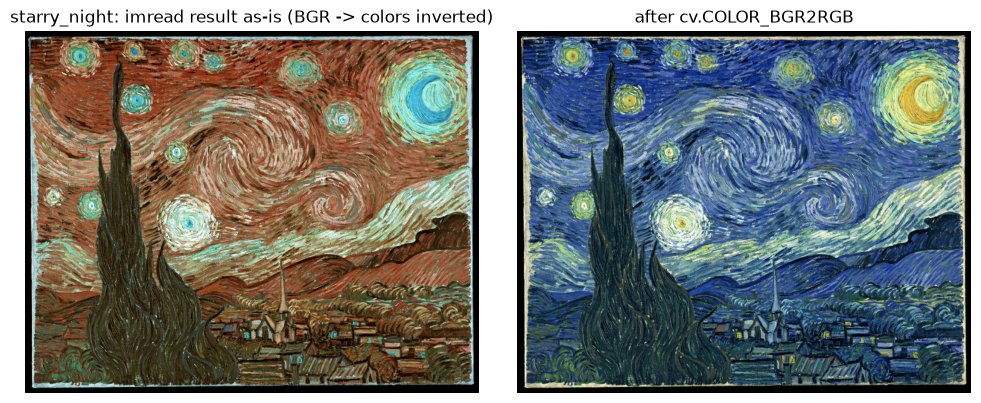

shape: (375, 1242, 3) (H, W, C)  | dtype: uint8 | range: 0 ~ 255
좌상단 픽셀 img_bgr[0, 0] = [B, G, R] = [147 137  58]
채널별 평균 [B, G, R] = [87.6 91.7 81.1]  (하늘 때문에 B 가 R 보다 크면 정상)


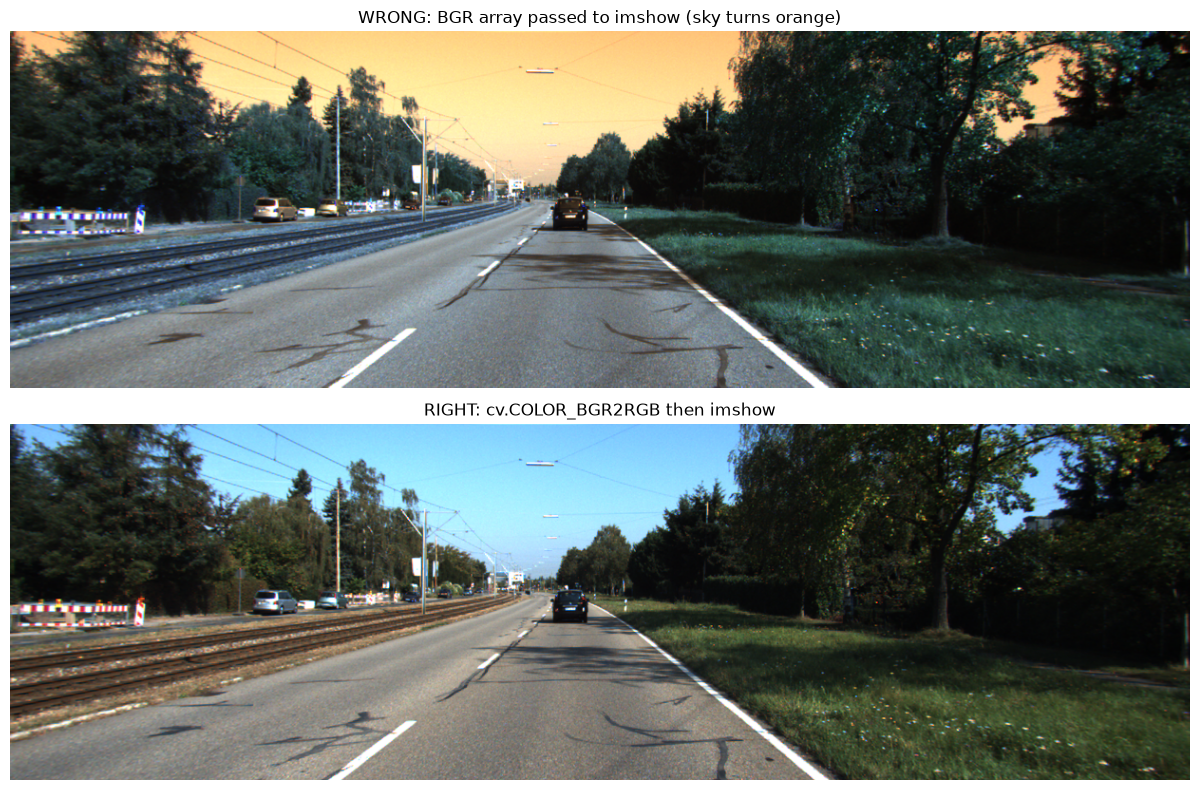

In [6]:
# 원본 예제 이미지로 먼저 확인: BGR 배열을 그대로 plt.imshow 에 주면 색이 뒤집힌다
# (그림 안 글자는 영문: 기본 폰트 DejaVu Sans 에 한글 glyph 가 없어 네모로 깨진다)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img); axes[0].set_title("starry_night: imread result as-is (BGR -> colors inverted)")
axes[1].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); axes[1].set_title("after cv.COLOR_BGR2RGB")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

# 우리 데이터(KITTI image_02 프레임 0)에 적용
img_bgr = cv.imread(str(IMG_PATH))
if img_bgr is None:
    raise FileNotFoundError(f"Could not read the image: {IMG_PATH}")   # CHANGED: sys.exit 은 노트북 커널을 죽이므로 예외로
print("shape:", img_bgr.shape, "(H, W, C)  | dtype:", img_bgr.dtype, "| range:", img_bgr.min(), "~", img_bgr.max())
print("좌상단 픽셀 img_bgr[0, 0] = [B, G, R] =", img_bgr[0, 0])
print("채널별 평균 [B, G, R] =", img_bgr.reshape(-1, 3).mean(0).round(1), " (하늘 때문에 B 가 R 보다 크면 정상)")

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)                  # CHANGED: cv.imshow 대신 matplotlib 로 표시하므로 RGB 로 변환
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].imshow(img_bgr); axes[0].set_title("WRONG: BGR array passed to imshow (sky turns orange)")
axes[1].imshow(img_rgb); axes[1].set_title("RIGHT: cv.COLOR_BGR2RGB then imshow")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [7]:
# 검증: 정답지 load_image 와 비교
from perceptrack3d.data.kitti_loader import load_image

ref_img = load_image(IMG_PATH)
print("정답지와 np.array_equal ?", np.array_equal(img_bgr, ref_img), "| 정답지 shape/dtype:", ref_img.shape, ref_img.dtype, "(BGR 그대로)")

# 차이: 원본 샘플은 실패 시 None → sys.exit. 정답지는 예외를 던진다 (호출자가 잡을 수 있음).
print("원본 방식: cv.imread('없는파일.png') ->", cv.imread("없는파일.png"))
try:
    load_image("없는파일.png")
except FileNotFoundError as e:
    print("정답지    : load_image('없는파일.png') -> FileNotFoundError:", e)

정답지와 np.array_equal ? True | 정답지 shape/dtype: (375, 1242, 3) uint8 (BGR 그대로)
원본 방식: cv.imread('없는파일.png') -> None
정답지    : load_image('없는파일.png') -> FileNotFoundError: 이미지 파일이 없습니다: 없는파일.png


[ WARN:0@0.860] global loadsave.cpp:278 findDecoder imread_('없는파일.png'): can't open/read file: check file path/integrity


### 조각 3. 프레임 목록 만들기 — 파일명 정렬로 번호 집합 맞추기

- **검색어**: `pykitti raw dataset image velodyne file list frames`
- **출처**: pykitti `raw.py :: raw._get_file_lists` — https://github.com/utiasSTARS/pykitti — MIT — 2026-09-08 — `notebooks_2nd/sources/pykitti/raw.py` 109~142행
- **왜 이걸 가져오나**: KITTI 는 "파일명 번호 = 프레임 번호" 이고 readme 는 "Numbers in the data stream correspond to each numbers in each other data stream" 이라고만 말한다. 실제로 두 폴더의 번호 집합이 같은지는 직접 세어 봐야 한다.
- **읽을 때 볼 곳**: 모든 목록이 `sorted(glob.glob(...))` 이다. `glob` 의 반환 순서는 OS 임의라 **`sorted` 가 없으면 이미지 i 번째와 LiDAR i 번째가 다른 프레임**이 될 수 있다.

In [8]:
# ORIGINAL: pykitti/raw.py :: raw._get_file_lists (109~142행), MIT
def _get_file_lists(self):
    """Find and list data files for each sensor."""
    self.oxts_files = sorted(glob.glob(
        os.path.join(self.data_path, 'oxts', 'data', '*.txt')))
    self.cam0_files = sorted(glob.glob(
        os.path.join(self.data_path, 'image_00',
                     'data', '*.{}'.format(self.imtype))))
    self.cam1_files = sorted(glob.glob(
        os.path.join(self.data_path, 'image_01',
                     'data', '*.{}'.format(self.imtype))))
    self.cam2_files = sorted(glob.glob(
        os.path.join(self.data_path, 'image_02',
                     'data', '*.{}'.format(self.imtype))))
    self.cam3_files = sorted(glob.glob(
        os.path.join(self.data_path, 'image_03',
                     'data', '*.{}'.format(self.imtype))))
    self.velo_files = sorted(glob.glob(
        os.path.join(self.data_path, 'velodyne_points',
                     'data', '*.bin')))

    # Subselect the chosen range of frames, if any
    if self.frames is not None:
        self.oxts_files = utils.subselect_files(
            self.oxts_files, self.frames)
        self.cam0_files = utils.subselect_files(
            self.cam0_files, self.frames)
        self.cam1_files = utils.subselect_files(
            self.cam1_files, self.frames)
        self.cam2_files = utils.subselect_files(
            self.cam2_files, self.frames)
        self.cam3_files = utils.subselect_files(
            self.cam3_files, self.frames)
        self.velo_files = utils.subselect_files(
            self.velo_files, self.frames)

In [9]:
import glob, os                                   # CHANGED: 원본 파일 머리의 import 를 여기서 가져옴
from types import SimpleNamespace

# 원본은 raw 클래스의 메서드다. 클래스를 통째로 가져오는 대신, 메서드가 쓰는 속성만 가진 객체를 만들어 self 로 넘긴다.
self = SimpleNamespace(data_path=ds["drive_dir"], imtype="png", frames=None)   # CHANGED: frames=None 이면 utils.subselect_files 는 호출되지 않음
_get_file_lists(self)

print({k: len(v) for k, v in vars(self).items() if k.endswith("_files")})
print("cam2_files[:2] =", [Path(p).name for p in self.cam2_files[:2]], "... velo_files[-1] =", Path(self.velo_files[-1]).name)

cam2_ids = [int(Path(p).stem) for p in self.cam2_files]      # 파일명 '0000000012.png' → 12
velo_ids = [int(Path(p).stem) for p in self.velo_files]
print("image_02 와 velodyne 번호 집합 동일?", set(cam2_ids) == set(velo_ids),
      "| 0 부터 연속?", cam2_ids == list(range(len(cam2_ids))), "| 범위:", cam2_ids[0], "~", cam2_ids[-1])

# sorted 를 빼면? glob 은 디렉터리 순서(임의)로 준다 → 파일시스템에 따라 뒤섞일 수 있다
unsorted = glob.glob(os.path.join(ds["drive_dir"], "velodyne_points", "data", "*.bin"))
print("sorted 없이 glob 한 앞 3개:", [Path(p).name for p in unsorted[:3]], "| 정렬돼 있나?", unsorted == sorted(unsorted))

{'oxts_files': 297, 'cam0_files': 297, 'cam1_files': 297, 'cam2_files': 297, 'cam3_files': 297, 'velo_files': 297}
cam2_files[:2] = ['0000000000.png', '0000000001.png'] ... velo_files[-1] = 0000000296.bin
image_02 와 velodyne 번호 집합 동일? True | 0 부터 연속? True | 범위: 0 ~ 296
sorted 없이 glob 한 앞 3개: ['0000000112.bin', '0000000171.bin', '0000000080.bin'] | 정렬돼 있나? False


In [10]:
# 검증: 정답지 KittiDataset.frame_ids() 와 비교
from perceptrack3d.data.kitti_loader import KittiDataset

dataset = KittiDataset(cfg)
print("정답지 frame_ids == cam2_ids ?", dataset.frame_ids() == cam2_ids, "| len:", len(dataset))
print("정답지 velodyne_path(0) == velo_files[0] ?", str(dataset.velodyne_path(0)) == self.velo_files[0])
# 차이: 정답지는 image_02 만 세고(velo 는 load_frame 때 없으면 FileNotFoundError), pykitti 는 6개 센서 목록을 전부 만든다.

정답지 frame_ids == cam2_ids ? True | len: 297
정답지 velodyne_path(0) == velo_files[0] ? True


### 조각 4. `timestamps.txt` 읽기 — 10 Hz 와 카메라·LiDAR 시각 차이

- **검색어**: `kitti raw timestamps.txt nanoseconds python datetime`
- **출처**:
  - `readme.txt` "General information about streams and timestamps" 절 (11~22행) + "Rectified color + grayscale stereo sequences" 절 (35~37행) — KITTI(연구용) — 2026-09-08 — `notebooks_2nd/sources/kitti_devkit/devkit/readme.txt`
  - pykitti `raw.py :: raw._load_timestamps` — https://github.com/utiasSTARS/pykitti — MIT — 2026-09-08 — `notebooks_2nd/sources/pykitti/raw.py` 246~263행
- **왜 이걸 가져오나**: 추적(Phase 7)의 `dt` 가 0.1 s 라는 가정을 파일로 확인하고, 이미지와 LiDAR 의 같은 줄이 정말 같은 시각인지 잰다.
- **읽을 때 볼 곳**: readme 16~22행("timestamp of each frame ... to nanosecond precision", "All cameras have been triggered directly by the Velodyne laser scanner"), 35~37행(약 10 Hz). pykitti 의 `line[:-4]` — `datetime` 은 마이크로초(6자리)까지만 받으므로 나노초 9자리 중 뒤 3자리와 개행을 잘라낸다.

readme.txt 원문 (14~22행, 35~37행):

```text
Each sensor stream is stored in a single folder. The main folder contains
meta information and a timestamp file, listing the timestamp of each frame
of the sequence to nanosecond precision. Numbers in the data stream correspond
to each numbers in each other data stream and to line numbers in the
timestamp file (0-based index), as all data has been synchronized. All
cameras have been triggered directly by the Velodyne laser scanner, while
from the GPS/IMU system (recording at 100 Hz), we have taken the data
information closest to the respective reference frame. For all sequences
'image_00' has been used as the synchronization reference stream.
...
All cameras are synchronized at about 10 Hz with respect to the Velodyne
laser scanner. The trigger is mounted such that camera images coincide
roughly with the Velodyne lasers facing forward (in driving direction).
```

In [11]:
# ORIGINAL: pykitti/raw.py :: raw._load_timestamps (246~263행), MIT
def _load_timestamps(self):
    """Load timestamps from file."""
    timestamp_file = os.path.join(
        self.data_path, 'oxts', 'timestamps.txt')

    # Read and parse the timestamps
    self.timestamps = []
    with open(timestamp_file, 'r') as f:
        for line in f.readlines():
            # NB: datetime only supports microseconds, but KITTI timestamps
            # give nanoseconds, so need to truncate last 4 characters to
            # get rid of \n (counts as 1) and extra 3 digits
            t = dt.datetime.strptime(line[:-4], '%Y-%m-%d %H:%M:%S.%f')
            self.timestamps.append(t)

    # Subselect the chosen range of frames, if any
    if self.frames is not None:
        self.timestamps = [self.timestamps[i] for i in self.frames]

In [12]:
import datetime as dt                              # CHANGED: 원본 파일 머리의 import

self = SimpleNamespace(data_path=ds["drive_dir"], frames=None)
_load_timestamps(self)                             # 원본 그대로: oxts/timestamps.txt 를 읽는다
print("oxts timestamps:", len(self.timestamps), "개 | 첫 값:", self.timestamps[0])

# 우리는 image_02 와 velodyne_points 의 timestamps.txt 도 필요하다 → 같은 파싱을 경로 인자 함수로
def read_timestamps(path):                         # CHANGED: 폴더가 oxts 로 고정된 원본을 경로 인자로 일반화
    with open(path, 'r') as f:
        return [dt.datetime.strptime(line[:-4], '%Y-%m-%d %H:%M:%S.%f') for line in f.readlines()]

drive = Path(ds["drive_dir"])
ts_img = read_timestamps(drive / "image_02" / "timestamps.txt")
ts_vel = read_timestamps(drive / "velodyne_points" / "timestamps.txt")
print("image_02 :", len(ts_img), "개 | 첫 3 줄:", [t.strftime("%H:%M:%S.%f") for t in ts_img[:3]])
print("velodyne :", len(ts_vel), "개 | 첫 3 줄:", [t.strftime("%H:%M:%S.%f") for t in ts_vel[:3]])

gaps = np.diff([t.timestamp() for t in ts_img])   # 연속 프레임 간격 (s)
print(f"이미지 프레임 간격: mean {gaps.mean()*1e3:.1f} ms, min {gaps.min()*1e3:.1f}, max {gaps.max()*1e3:.1f}  →  {1/gaps.mean():.2f} Hz")
offset = np.array([(a - b).total_seconds() * 1e3 for a, b in zip(ts_img, ts_vel)])
print(f"image_02 − velodyne (같은 줄): mean {offset.mean():+.1f} ms, max |{np.abs(offset).max():.1f}| ms  (수 ms 이내면 같은 시각으로 본다)")

oxts timestamps: 297 개 | 첫 값: 2011-09-26 13:12:03.968689
image_02 : 297 개 | 첫 3 줄: ['13:12:03.957664', '13:12:04.061060', '13:12:04.164430']
velodyne : 297 개 | 첫 3 줄: ['13:12:03.947134', '13:12:04.050539', '13:12:04.153953']
이미지 프레임 간격: mean 103.6 ms, min 99.1, max 108.1  →  9.66 Hz
image_02 − velodyne (같은 줄): mean +10.5 ms, max |15.0| ms  (수 ms 이내면 같은 시각으로 본다)


In [13]:
# 검증 1: 정답지 노트북(01)은 s[:26] 로 잘라 파싱한다 — pykitti 의 line[:-4] 와 같은 결과인지
raw_lines = (drive / "image_02" / "timestamps.txt").read_text().splitlines()
ts_ref = [dt.datetime.strptime(s[:26], "%Y-%m-%d %H:%M:%S.%f") for s in raw_lines]
print("line[:-4] 방식 == s[:26] 방식 ?", ts_ref == ts_img)

# 검증 2: 측정한 간격이 configs/kitti.yaml 의 tracking.dt (Phase 7 칼만 필터의 시간 간격) 와 맞는지
dt_cfg = cfg["tracking"]["dt"]
print(f"측정 mean dt = {gaps.mean():.4f} s | config tracking.dt = {dt_cfg} s | 차이 < 5 ms ?", abs(gaps.mean() - dt_cfg) < 0.005)

line[:-4] 방식 == s[:26] 방식 ? True
측정 mean dt = 0.1036 s | config tracking.dt = 0.1 s | 차이 < 5 ms ? True


### 조각 5. BEV 산점도 — `Axes.scatter` 로 x‑y 평면에 높이를 색으로

- **검색어**: `matplotlib scatter color by value colorbar`
- **출처**:
  - matplotlib plot_types 예제 `scatter(x, y)` — https://matplotlib.org/stable/plot_types/basic/scatter_plot.html — matplotlib 라이선스(PSF 계열) — 2026-09-08 — `notebooks_2nd/sources/matplotlib/scatter_plot.py`
  - `matplotlib.axes.Axes.scatter` API 문서 — https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html — 2026-09-08
- **왜 이걸 가져오나**: 점군이 제대로 읽혔는지 보는 가장 빠른 방법은 위에서 내려다본 x‑y 산점도다. 색 = 높이 z 로 두면 도로면(≈ −1.7 m)과 건물·차량이 구분된다.
- **읽을 때 볼 곳**: 예제의 `ax.scatter(x, y, s=sizes, c=colors, vmin=0, vmax=100)` — `c` 에 숫자 배열을 주면 `cmap` 으로 색이 매겨지고 `vmin/vmax` 가 색 범위. API 문서: `s` 는 "marker size in points**2".

**축 규약**: Velodyne 은 x 전방, y 좌(오른손 좌표계). 종이 위에 x 를 위로 두면 y 는 **왼쪽**을 향해야 한다. matplotlib 의 가로축은 오른쪽이 +이므로 가로축에 `-y` 를 넣어야 실제 왼쪽 물체가 그림 왼쪽에 온다.

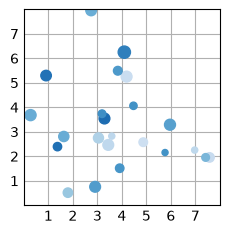

In [14]:
# ORIGINAL: matplotlib/galleries/plot_types/basic/scatter_plot.py, matplotlib license (PSF-based)
"""
=============
scatter(x, y)
=============
A scatter plot of y versus x with varying marker size and/or color.

See `~matplotlib.axes.Axes.scatter`.
"""
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make the data
np.random.seed(3)
x = 4 + np.random.normal(0, 2, 24)
y = 4 + np.random.normal(0, 2, len(x))
# size and color:
sizes = np.random.uniform(15, 80, len(x))
colors = np.random.uniform(15, 80, len(x))

# plot
fig, ax = plt.subplots()

ax.scatter(x, y, s=sizes, c=colors, vmin=0, vmax=100)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

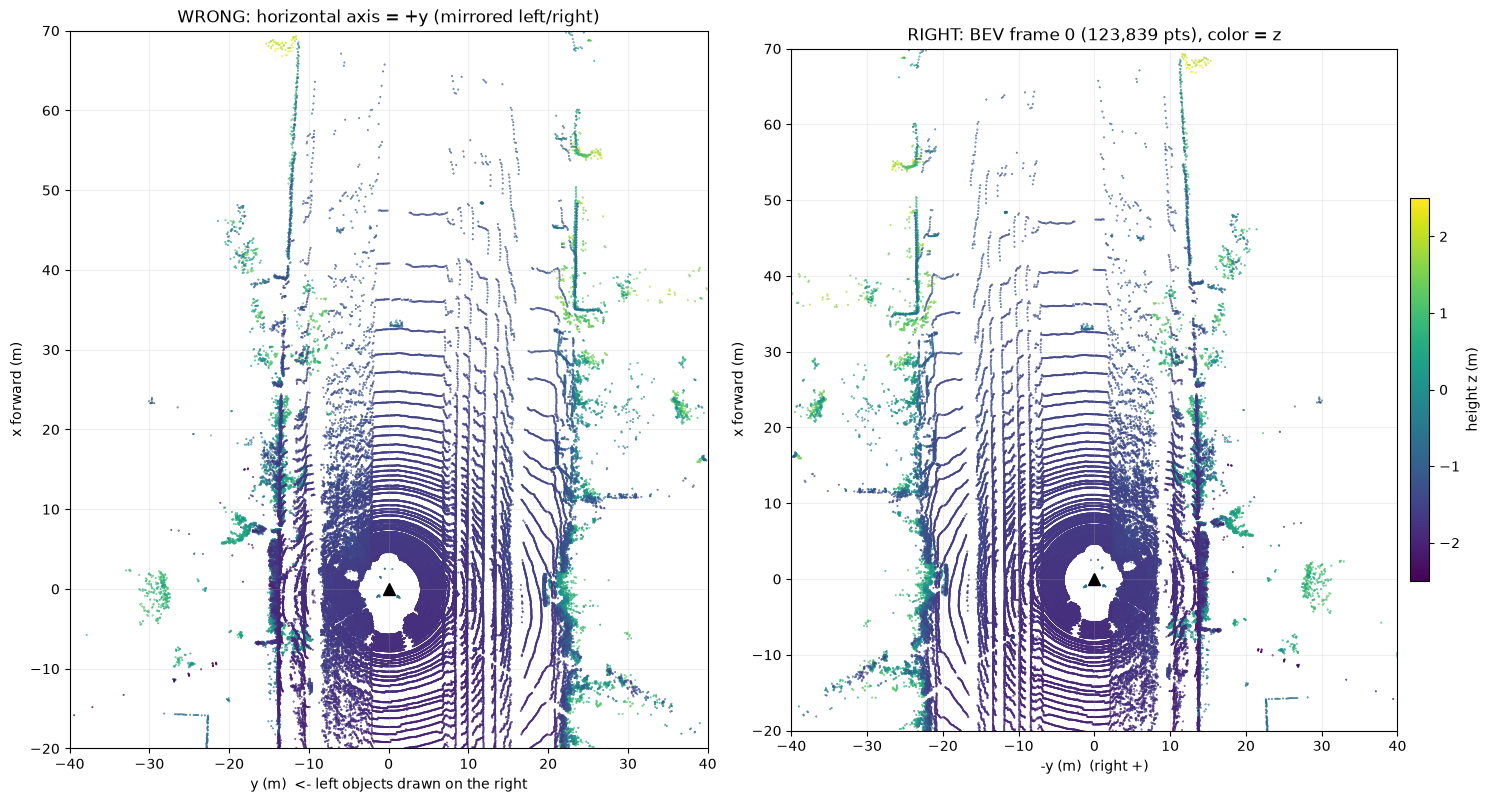

In [15]:
plt.style.use('default')                          # CHANGED: 원본의 갤러리용 스타일(작은 그림)을 되돌림

x_plot = -points[:, 1]                            # CHANGED: 가로축 = −y  (왼쪽 물체가 그림 왼쪽에 오도록)
y_plot = points[:, 0]                             # CHANGED: 세로축 = x   (전방이 위)
colors = points[:, 2]                             # CHANGED: 색 = 높이 z (m)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# 왼쪽: 흔한 실수 — y 를 그대로 가로축에 (좌우가 거울처럼 뒤집힘)
axes[0].scatter(points[:, 1], points[:, 0], s=0.15, c=colors, vmin=-2.5, vmax=2.5)
axes[0].set(xlim=(-40, 40), ylim=(-20, 70), aspect="equal", xlabel="y (m)  <- left objects drawn on the right", ylabel="x forward (m)",
            title="WRONG: horizontal axis = +y (mirrored left/right)")
# 오른쪽: 가로축 = −y
sc = axes[1].scatter(x_plot, y_plot, s=0.15, c=colors, vmin=-2.5, vmax=2.5)   # CHANGED: s 작게(12만 점), vmin/vmax = 높이 범위 −2.5~2.5 m
axes[1].set(xlim=(-40, 40), ylim=(-20, 70), aspect="equal", xlabel="-y (m)  (right +)", ylabel="x forward (m)",
            title=f"RIGHT: BEV frame {FRAME} ({len(points):,} pts), color = z")
for ax in axes:
    ax.plot(0, 0, marker="^", color="black", markersize=8)   # 센서(우리 차) 위치
    ax.grid(True, alpha=0.2)
fig.colorbar(sc, ax=axes[1], fraction=0.03, pad=0.02, label="height z (m)")
plt.tight_layout(); plt.show()

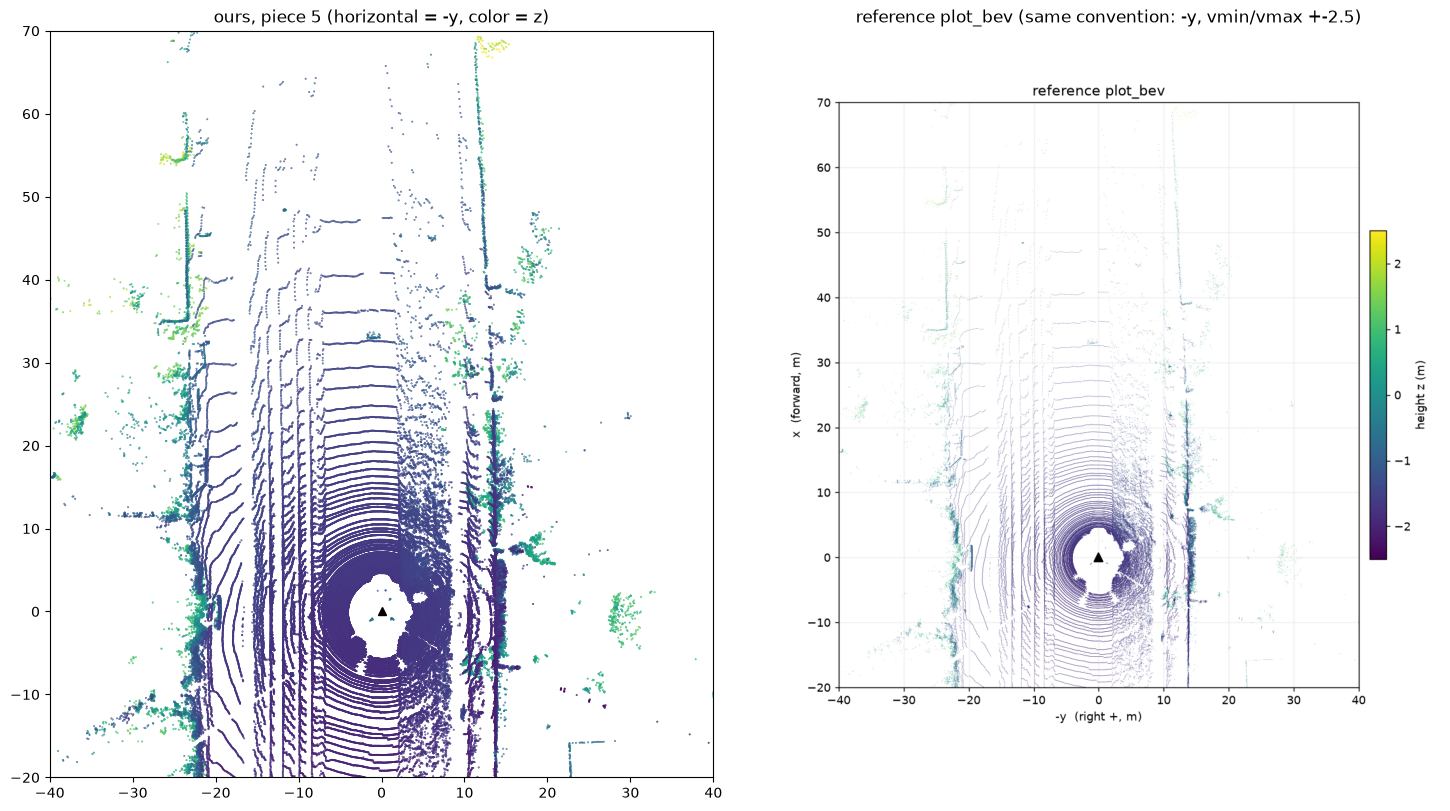

정답지 plot_bev 도 ax.scatter(-xyz[:, 1], xyz[:, 0], c=xyz[:, 2], vmin=-2.5, vmax=2.5) 를 쓴다 → 같은 규약. 도로·건물 배치가 같으면 통과.


In [16]:
# 검증: 정답지 plot_bev 가 만든 그림과 나란히 (정답지는 파일로 저장하므로 임시 파일에 저장한 뒤 읽어 표시)
from perceptrack3d.visualization.pointcloud import plot_bev
import tempfile

with tempfile.TemporaryDirectory() as d:
    ref_png = plot_bev(points, Path(d) / "bev_ref.png", title="reference plot_bev")
    ref_bev = plt.imread(ref_png)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].scatter(x_plot, y_plot, s=0.15, c=colors, vmin=-2.5, vmax=2.5)
axes[0].set(xlim=(-40, 40), ylim=(-20, 70), aspect="equal", title="ours, piece 5 (horizontal = -y, color = z)")
axes[0].plot(0, 0, "k^")
axes[1].imshow(ref_bev); axes[1].axis("off"); axes[1].set_title("reference plot_bev (same convention: -y, vmin/vmax +-2.5)")
plt.tight_layout(); plt.show()
print("정답지 plot_bev 도 ax.scatter(-xyz[:, 1], xyz[:, 0], c=xyz[:, 2], vmin=-2.5, vmax=2.5) 를 쓴다 → 같은 규약. 도로·건물 배치가 같으면 통과.")

### 이어붙이기 — 조각 1·2·3 으로 `load_frame(i)` 만들기

정답지 `KittiDataset.load_frame` 이 돌려주는 것과 같은 dict 를 만든다. 접착 코드는 직접 쓴다.

In [17]:
def load_frame(frame_id):
    """이미지(BGR)와 LiDAR (N,4) 를 함께 읽는다. 조각 1(load_velo_scan) + 조각 2(cv.imread) + 조각 3(파일명 규칙)."""
    name = f"{frame_id:0{ds['frame_id_width']}d}"
    ip = Path(ds["image_dir"]) / f"{name}.png"
    vp = Path(ds["velo_dir"]) / f"{name}.bin"
    image = cv.imread(str(ip))
    if image is None:                                            # 조각 2: 실패 시 None
        raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {ip}")
    n_bytes = vp.stat().st_size if vp.is_file() else -1
    if n_bytes <= 0 or n_bytes % 16 != 0:                        # 조각 1 검증 셀에서 배운 것: 읽기 전에 크기 검사
        raise ValueError(f"LiDAR 파일 크기가 16 의 배수가 아닙니다 (bytes={n_bytes}): {vp}")
    return {"frame_id": frame_id, "image": image, "points": load_velo_scan(str(vp)),
            "image_path": ip, "velodyne_path": vp}

for fid in (0, 100, cam2_ids[-1]):
    mine, ref = load_frame(fid), dataset.load_frame(fid)
    same = (set(mine) == set(ref)
            and np.array_equal(mine["image"], ref["image"])
            and np.array_equal(mine["points"], ref["points"])
            and mine["image_path"] == ref["image_path"] and mine["velodyne_path"] == ref["velodyne_path"])
    print(f"frame {fid:3d}: keys 동일 & image/points array_equal & 경로 동일 ? {same}  | image {mine['image'].shape}, points {mine['points'].shape}")

frame   0: keys 동일 & image/points array_equal & 경로 동일 ? True  | image (375, 1242, 3), points (123839, 4)
frame 100: keys 동일 & image/points array_equal & 경로 동일 ? True  | image (375, 1242, 3), points (123125, 4)
frame 296: keys 동일 & image/points array_equal & 경로 동일 ? True  | image (375, 1242, 3), points (42122, 4)


### 여기서 배우는 것

- **dtype 과 파일 크기**: `.bin` 은 헤더가 없다. `np.fromfile(dtype=np.float32)` 는 자투리 바이트를 조용히 버리므로, 잘린 파일은 `reshape(-1, 4)` 가 성공한 채 점이 하나 사라진다. 읽기 전에 `st_size % 16` 을 검사해야 한다 (조각 1 C).
- **채널 순서**: OpenCV 는 B, G, R. 문서에 굵은 글씨 한 줄뿐이지만 matplotlib·YOLO 입력에서 바로 터진다. `cv.imwrite` 도 BGR 을 기대하므로 RGB 로 바꾼 배열을 저장하면 파일 색이 뒤집힌다.
- **`sorted` 한 줄**: `glob` 순서는 OS 임의다. pykitti 가 모든 목록에 `sorted` 를 붙인 이유. 빠지면 i 번째 이미지와 i 번째 LiDAR 가 다른 프레임이 된다.
- **남의 메서드 붙이기**: `self` 를 받는 메서드는 클래스를 통째로 가져오지 않아도 `SimpleNamespace` 로 필요한 속성만 흉내 내면 원문 그대로 실행된다. 단 원본이 참조하는 모듈 이름(`glob`, `os`, `dt`, `utils`)을 빠뜨리면 `NameError`.
- **축 규약**: BEV 에서 가로축에 `+y` 를 넣으면 좌우가 거울처럼 뒤집힌다. 오른손 좌표계(x 전방, y 좌)를 종이에 그리려면 가로축은 `−y`.

### 자가 점검 3문제

1. `.bin` 파일이 1,981,424 바이트일 때 점 수는? 크기가 1,981,425 바이트라면 `load_velo_scan` 은 무엇을 돌려주고, 정답지 `load_velodyne` 은 무엇을 하는가?
2. `cv.imread` 로 읽은 `img[0, 0]` 이 `[200, 150, 100]` 이면 이 픽셀의 R 값은 얼마인가? 이 배열을 `plt.imshow` 에 그대로 넣으면 어떤 색으로 보이는가?
3. BEV 그림에서 차의 **오른쪽** 3 m 에 있는 물체는 Velodyne 좌표로 y 가 얼마이고, 조각 5 의 그림에서는 가로축 어느 값에 찍히는가?

<details>
<summary>답</summary>

1. 1,981,424 / 16 = 123,839 점. 1,981,425 바이트면 `np.fromfile` 이 마지막 1 바이트를 버리고 같은 123,839 점 배열을 돌려준다 (오류 없음). 정답지는 읽기 전에 `st_size % 16 != 0` 을 검사해 `ValueError` 를 던진다.
2. R = 100 (순서가 B, G, R 이므로 세 번째 값). `plt.imshow` 는 RGB 로 해석하므로 R=200, B=100 인 불그스름한 색으로 보인다 (실제는 푸르스름한 색).
3. y = −3 m (Velodyne +y 가 왼쪽). 가로축은 `−y` 이므로 +3 에 찍힌다 (그림 오른쪽).

</details>